In [4]:
!pip install dynamiqs
!pip install cmaes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 kB 3.6 MB/s eta 0:00:00


In [5]:
import dynamiqs as dq
import numpy as np
from matplotlib import pyplot as plt

from cmaes import SepCMA
from scipy.optimize import least_squares

In [6]:
def model(p, t):
    A, tau, C = p
    return A * np.exp(-t / tau) + C


# scipy expects a numpy array

def residuals(p, x, y):
    return np.asarray(model(p, x) - y, dtype=float)


# robust exponential fit

def robust_exp_fit(x, y):

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # smart initialization
    A0 = float(y.max() - y.min())
    C0 = float(y.min())
    tau0 = float(x.max() - x.min())

    p0 = [A0, tau0, C0]

    res = least_squares(
        residuals,
        p0,
        args=(x, y),
        bounds=([0, 1e-12, -np.inf], [np.inf, np.inf, np.inf]),
        loss="soft_l1",
        f_scale=0.1,
    )

    y_fit = model(res.x.copy(), x)

    return {
        "popt": res.x,
        "y_fit": y_fit,
    }


In [16]:
def get_lifetime_with_variables(initial_state, tfinal, g_2, eps_d):

    na = 15
    nb = 5

    # annihilation operators
    a = dq.tensor(dq.destroy(na), dq.eye(nb))
    b = dq.tensor(dq.eye(na), dq.destroy(nb))

    # dissipation rates
    kappa_b = 10.0
    kappa_a = 1.0

    # alpha estimation
    eps_2 = 2 * g_2 * eps_d / kappa_b
    kappa_2 = 4 * np.abs(g_2) ** 2 / kappa_b

    inside = 2 / kappa_2 * (eps_2 - kappa_a / 4)

    # avoid invalid sqrt
    inside = np.real_if_close(inside)
    inside = np.maximum(np.real(inside), 1e-12)

    alpha_estimate = np.sqrt(inside)

    # Hamiltonian
    H = (
        np.conj(g_2) * a @ a @ b.dag()
        + g_2 * a.dag() @ a.dag() @ b
        - eps_d * b.dag()
        - np.conj(eps_d) * b
    )

    # dissipation operators
    loss_b = np.sqrt(kappa_b) * b
    loss_a = np.sqrt(kappa_a) * a

    tsave = np.linspace(0, tfinal, 100)

    # cat basis
    g_state = dq.coherent(na, alpha_estimate)
    e_state = dq.coherent(na, -alpha_estimate)

    basis = {
        "+z": g_state,
        "-z": e_state,
        "+x": (g_state + e_state) / np.sqrt(2),
        "-x": (g_state - e_state) / np.sqrt(2),
        "+y": (g_state + 1j * e_state) / np.sqrt(2),
        "-y": (g_state - 1j * e_state) / np.sqrt(2),
    }

    # Pauli operators in cat subspace
    sx = basis["+x"] @ basis["+x"].dag() - basis["-x"] @ basis["-x"].dag()
    sx = dq.tensor(sx, dq.eye(nb))

    sz = basis["+z"] @ basis["+z"].dag() - basis["-z"] @ basis["-z"].dag()
    sz = dq.tensor(sz, dq.eye(nb))

    # initial state
    psi0 = dq.tensor(basis[initial_state], dq.fock(nb, 0))

    # master equation solve
    res = dq.mesolve(
        H,
        [loss_b, loss_a],
        psi0,
        tsave,
        options=dq.Options(progress_meter=False, save_states=False),
        exp_ops=[sx, sz],
    )

    return res


# ============================================================
# EXTRACT T_X AND T_Z
# ============================================================


def get_TX_TZ(g_2, eps_d):

    # Tz
    res_z = get_lifetime_with_variables("+z", 200, g_2, eps_d)

    szt = np.real(np.asarray(res_z.expects[1, :]))
    ts_z = np.asarray(res_z.tsave)

    fit_z = robust_exp_fit(ts_z, szt)
    Tz = fit_z["popt"][1]

    # Tx
    res_x = get_lifetime_with_variables("+x", 1.0, g_2, eps_d)

    sxt = np.real(np.asarray(res_x.expects[0, :]))
    ts_x = np.asarray(res_x.tsave)

    fit_x = robust_exp_fit(ts_x, sxt)
    Tx = fit_x["popt"][1]

    return float(Tx), float(Tz)


# ============================================================
# REWARD FUNCTION
# ============================================================

""""
def reward_function(p):
"""
#p = [g2_real, g2_imag, eps_real, eps_imag, lambda]
"""

    g_2 = p[0] + 1j * p[1]
    eps_d = p[2] + 1j * p[3]
    lamb = p[4]

    eta = 500

    Tx, Tz = get_TX_TZ(g_2, eps_d)
    g = (np.log10(eta*Tx/Tz))**2
    #g = eta * Tx - Tz
    f = Tx + Tz

    L = -f + lamb * g

    return float(L)
"""
    
def loss_fn_AI(Tz, Tx, C, ratio_weight=100.0,
            Tx_reward=1.0, Tz_reward=1.0,
            eps=1e-8):
    ratio_error = (Tz / (Tx + eps) - C) ** 2

    reward = Tx_reward * Tx + Tz_reward * Tz

    return ratio_weight * ratio_error - reward

def loss_fn_norm(Tz, Tx, C, ratio_weight=100.0, 
            reward_weight=1.0, eps=1e-8, p=3):
    
    ratio_error = np.square(Tx / (Tz + eps) - C)
    
    reward = np.linalg.norm(np.array([Tz, Tx]), ord=p)

    return ratio_weight * ratio_error - reward * reward_weight

# super params
na = 15 # memory dim
nb = 5 # buffer dim
kappa_b = 10 # MHz
kappa_a = 1 # MHz
tfinal = 200
mu = 3

def simul(eps_d, g_2):    
    a = dq.tensor(dq.destroy(na), dq.eye(nb))
    b = dq.tensor(dq.eye(na), dq.destroy(nb))

    sx_op = (1j * np.pi * a.dag() @ a).expm()
    x_op  = a + dq.dag(a)
    p_op  = a - dq.dag(a)
    
    # # alpha estimation
    eps_2    = 2 * g_2 * eps_d / kappa_b
    kappa_2  = 4 * np.abs(g_2)**2 / kappa_b
    alpha    = np.sqrt(2 / kappa_2 * (eps_2 - kappa_a / 4))

    H = (np.conj(g_2) * (a @ a @ dq.dag(b))
       + g_2 * (dq.dag(a) @ dq.dag(a) @ b)
       - eps_d * dq.dag(b)
       - np.conj(eps_d) * b)

    # states
    g_state = dq.coherent(na, alpha)
    e_state = dq.coherent(na, -alpha)

    # initial state: +x superposition
    psi0  = dq.tensor(g_state, dq.fock(nb, 0))
    tsave = np.linspace(0, tfinal, 100)

    res = dq.mesolve(
        H, [np.sqrt(kappa_b) * b, np.sqrt(kappa_a) * a],
        psi0, tsave,
        options=dq.Options(progress_meter=False),
        exp_ops=[sx_op, x_op, p_op],
    )

    ts    = res.tsave
    sx_val = res.expects[0].real
    x_val  = res.expects[1].real
    p_val  = res.expects[2].real

    # fit amplitude decay → Tz
    amp    = np.hypot(x_val, p_val)
    fit_z  = robust_exp_fit(ts, amp)
    Tz     = np.abs(fit_z["popt"][1])

    # fit sx decay → Tx
    fit_x  = robust_exp_fit(ts, sx_val)
    Tx     = np.abs(fit_x["popt"][1])

    return loss_fn_norm(Tz, Tx, mu)

In [19]:
# JAX-Free Version (NumPy + dynamiqs only)

import numpy as np
import dynamiqs as dq


# ============================================================
# ROBUST EXPONENTIAL FIT
# ============================================================
# Assumes robust_exp_fit already exists.
# Example expected return:
# fit = robust_exp_fit(t, y)
# fit["popt"][1] -> decay constant


# ============================================================
# LIFETIME SIMULATION
# ============================================================

def get_lifetime_with_variables(initial_state, tfinal, g_2, eps_d):

    na = 15
    nb = 5

    # annihilation operators
    a = dq.tensor(dq.destroy(na), dq.eye(nb))
    b = dq.tensor(dq.eye(na), dq.destroy(nb))

    # dissipation rates
    kappa_b = 10.0
    kappa_a = 1.0

    # alpha estimation
    eps_2 = 2 * g_2 * eps_d / kappa_b
    kappa_2 = 4 * np.abs(g_2) ** 2 / kappa_b

    inside = 2 / kappa_2 * (eps_2 - kappa_a / 4)

    # avoid invalid sqrt
    inside = np.real_if_close(inside)
    inside = np.maximum(np.real(inside), 1e-12)

    alpha_estimate = np.sqrt(inside)

    # Hamiltonian
    H = (
        np.conj(g_2) * a @ a @ b.dag()
        + g_2 * a.dag() @ a.dag() @ b
        - eps_d * b.dag()
        - np.conj(eps_d) * b
    )

    # dissipation operators
    loss_b = np.sqrt(kappa_b) * b
    loss_a = np.sqrt(kappa_a) * a

    tsave = np.linspace(0, tfinal, 100)

    # cat basis
    g_state = dq.coherent(na, alpha_estimate)
    e_state = dq.coherent(na, -alpha_estimate)

    basis = {
        "+z": g_state,
        "-z": e_state,
        "+x": (g_state + e_state) / np.sqrt(2),
        "-x": (g_state - e_state) / np.sqrt(2),
        "+y": (g_state + 1j * e_state) / np.sqrt(2),
        "-y": (g_state - 1j * e_state) / np.sqrt(2),
    }

    # Pauli operators in cat subspace
    sx = (
        basis["+x"] @ basis["+x"].dag()
        - basis["-x"] @ basis["-x"].dag()
    )
    sx = dq.tensor(sx, dq.eye(nb))

    sz = (
        basis["+z"] @ basis["+z"].dag()
        - basis["-z"] @ basis["-z"].dag()
    )
    sz = dq.tensor(sz, dq.eye(nb))

    # initial state
    psi0 = dq.tensor(basis[initial_state], dq.fock(nb, 0))

    # master equation solve
    res = dq.mesolve(
        H,
        [loss_b, loss_a],
        psi0,
        tsave,
        options=dq.Options(progress_meter=False, save_states=False),
        exp_ops=[sx, sz],
    )

    return res


# ============================================================
# EXTRACT TX AND TZ
# ============================================================

def get_TX_TZ(g_2, eps_d):

    # Tz
    res_z = get_lifetime_with_variables("+z", 200, g_2, eps_d)

    szt = np.real(np.asarray(res_z.expects[1]))
    ts_z = np.asarray(res_z.tsave)

    fit_z = robust_exp_fit(ts_z, szt)
    Tz = fit_z["popt"][1]

    # Tx
    res_x = get_lifetime_with_variables("+x", 1.0, g_2, eps_d)

    sxt = np.real(np.asarray(res_x.expects[0]))
    ts_x = np.asarray(res_x.tsave)

    fit_x = robust_exp_fit(ts_x, sxt)
    Tx = fit_x["popt"][1]

    return float(Tx), float(Tz)


# ============================================================
# LOSS FUNCTIONS
# ============================================================

def loss_fn_AI(
    Tz,
    Tx,
    C,
    ratio_weight=100.0,
    Tx_reward=1.0,
    Tz_reward=1.0,
    eps=1e-8,
):
    ratio_error = (Tz / (Tx + eps) - C) ** 2

    reward = Tx_reward * Tx + Tz_reward * Tz

    return ratio_weight * ratio_error - reward



def loss_fn_norm(
    Tz,
    Tx,
    C,
    ratio_weight=100.0,
    reward_weight=1.0,
    eps=1e-8,
    p=3,
):

    ratio_error = np.square(Tx / (Tz + eps) - C)

    reward = np.linalg.norm(np.array([Tz, Tx]), ord=p)

    return ratio_weight * ratio_error - reward * reward_weight


# ============================================================
# GLOBAL PARAMETERS
# ============================================================

na = 15
nb = 5
kappa_b = 10
kappa_a = 1
tfinal = 200
mu = 3


# ============================================================
# MAIN SIMULATION
# ============================================================

def simul(eps_d, g_2):

    a = dq.tensor(dq.destroy(na), dq.eye(nb))
    b = dq.tensor(dq.eye(na), dq.destroy(nb))

    sx_op = (1j * np.pi * a.dag() @ a).expm()
    x_op = a + a.dag()
    p_op = a - a.dag()

    # alpha estimation
    eps_2 = 2 * g_2 * eps_d / kappa_b
    kappa_2 = 4 * np.abs(g_2) ** 2 / kappa_b

    inside = 2 / kappa_2 * (eps_2 - kappa_a / 4)
    inside = np.real_if_close(inside)
    inside = np.maximum(np.real(inside), 1e-12)

    alpha = np.sqrt(inside)

    # Hamiltonian
    H = (
        np.conj(g_2) * (a @ a @ b.dag())
        + g_2 * (a.dag() @ a.dag() @ b)
        - eps_d * b.dag()
        - np.conj(eps_d) * b
    )

    # states
    g_state = dq.coherent(na, alpha)
    e_state = dq.coherent(na, -alpha)

    # initial state
    psi0 = dq.tensor(g_state, dq.fock(nb, 0))

    tsave = np.linspace(0, tfinal, 100)

    # master equation
    res = dq.mesolve(
        H,
        [np.sqrt(kappa_b) * b, np.sqrt(kappa_a) * a],
        psi0,
        tsave,
        options=dq.Options(progress_meter=False),
        exp_ops=[sx_op, x_op, p_op],
    )

    ts = np.asarray(res.tsave)

    sx_val = np.real(np.asarray(res.expects[0]))
    x_val = np.real(np.asarray(res.expects[1]))
    p_val = np.real(np.asarray(res.expects[2]))

    # fit amplitude decay -> Tz
    amp = np.hypot(x_val, p_val)
    fit_z = robust_exp_fit(ts, amp)
    Tz = np.abs(fit_z["popt"][1])

    # fit parity decay -> Tx
    fit_x = robust_exp_fit(ts, sx_val)
    Tx = np.abs(fit_x["popt"][1])

    return loss_fn_norm(Tz, Tx, mu)




In [21]:
print(simul(1,4))

1566637.0573998203


/usr/local/lib/python3.12/dist-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


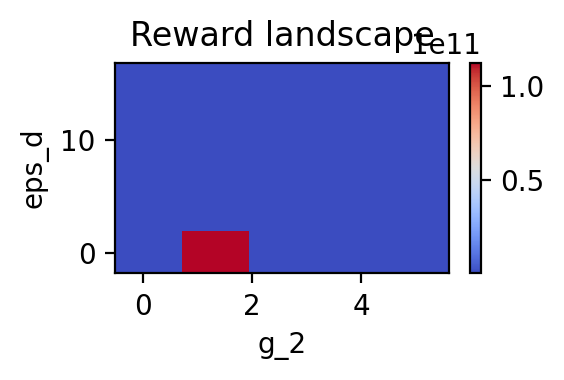

In [23]:
g_2_array = np.linspace(0.1, 5, 5)
eps_d_array = np.linspace(0.1, 15, 5)

losses = np.zeros((len(eps_d_array), len(g_2_array)))

for i, eps in enumerate(eps_d_array):
    for j, g in enumerate(g_2_array):

        try:
            losses[i, j] = simul(g,eps)
        except Exception as exc:
            print(f"Sweep failure at g={g}, eps={eps}: {exc}")
            losses[i, j] = np.nan


fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=200)

im = ax.pcolormesh(g_2_array, eps_d_array, losses, cmap="coolwarm")

cbar = fig.colorbar(im, ax=ax)

ax.set_xlabel("g_2")
ax.set_ylabel("eps_d")
ax.set_title("Reward landscape")

plt.tight_layout()
plt.show()



In [24]:
# ============================================================
# CMA-ES OPTIMIZATION
# ============================================================

BATCH_SIZE = 12
N_EPOCHS = 200
N_KNOBS = 2

# initial values
mean0 = np.array([0.5, 2.0], dtype=float)
sigma0 = 0.2


# synthetic drift
amp_factor_delta_drift_func = (
    lambda ep: 0.8 * np.sin(2 * np.pi * 0.01 * ep)
)


# CMA-ES setup
optimizer = SepCMA(
    mean=mean0,
    sigma=sigma0,
    bounds=np.array(
        [
            [-1.0, 1.0],
            [-5.0, 5.0],
        ],
        dtype=float,
    ),
    population_size=BATCH_SIZE,
    seed=0,
)


# logging
mean_history = []
std_history = []
reward_history = []
reward_std_history = []
drift_history = []


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(N_EPOCHS):

    drift_history.append([
        amp_factor_delta_drift_func(epoch),
        0.0,
    ])

    xs = []

    # sample CMA population
    for _ in range(optimizer.population_size):

        candidate = np.array(optimizer.ask(), dtype=float)

        # append drift coordinates
        candidate_with_drift = np.concatenate(
            [candidate, np.array(drift_history[-1])]
        )

        xs.append(candidate_with_drift)

    xs = np.asarray(xs)
    rewards = np.zeros(xs.shape[0])

    for i, x in enumerate(xs):
        rewards[i] = simul(x[0], x[1])

    # CMA expects tuples: (solution, value)
    solutions = []

    for j in range(len(xs)):
        solutions.append((xs[j][:N_KNOBS], float(rewards[j])))

    optimizer.tell(solutions)

    # logging
    mean_history.append(np.mean(xs[:, :N_KNOBS], axis=0))
    std_history.append(np.std(xs[:, :N_KNOBS], axis=0))

    reward_history.append(np.mean(rewards))
    reward_std_history.append(np.std(rewards))

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"param mean={mean_history[-1]} | "
            f"param std={std_history[-1]} | "
            f"avg reward={np.mean(rewards):.4f}"
        )


# convert logs to arrays
mean_history = np.asarray(mean_history)
std_history = np.asarray(std_history)
reward_history = np.asarray(reward_history)
reward_std_history = np.asarray(reward_std_history)
drift_history = np.asarray(drift_history)


# ============================================================
# PLOT 1: REWARD VS EPOCH
# ============================================================

epochs = np.arange(N_EPOCHS)

plt.figure(figsize=(7, 4))

plt.plot(epochs, reward_history, label="Mean reward")

plt.fill_between(
    epochs,
    reward_history - reward_std_history,
    reward_history + reward_std_history,
    alpha=0.2,
)

plt.xlabel("Epoch")
plt.ylabel("Reward")
plt.title("CMA-ES: Reward vs Epoch")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()


# ============================================================
# PLOT 2: PARAMETER EVOLUTION
# ============================================================

plt.figure(figsize=(7, 4))

# parameter 1
plt.plot(epochs, mean_history[:, 0], label="amp factor Δ")

plt.fill_between(
    epochs,
    mean_history[:, 0] - std_history[:, 0],
    mean_history[:, 0] + std_history[:, 0],
    alpha=0.2,
)

# parameter 2
plt.plot(epochs, mean_history[:, 1], label="freq Δ (MHz)")

plt.fill_between(
    epochs,
    mean_history[:, 1] - std_history[:, 1],
    mean_history[:, 1] + std_history[:, 1],
    alpha=0.2,
)

# true optimum
plt.plot(
    drift_history[:, 0],
    linestyle="--",
    label="amp factor Δ optimal",
)

plt.plot(
    drift_history[:, 1],
    linestyle="--",
    label="freq Δ optimal",
)

plt.xlabel("Epoch")
plt.ylabel("Parameter value")
plt.title("CMA-ES Parameter Convergence")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

/usr/local/lib/python3.12/dist-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


Epoch   0 | param mean=[0.61541259 2.04474727] | param std=[0.22261413 0.17998384] | avg reward=2389583306.0047


KeyboardInterrupt: 